⭐  ___Makhova Anastasia___ ⭐

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle')
%matplotlib inline

import seaborn as sns


from statsmodels.tsa.stattools import adfuller, kpss

In [2]:
df = pd.read_csv("HA1.csv", parse_dates=['date'], index_col='date')
print(df.head())

                 ts1       ts2       ts3       ts4       ts5       ts6
date                                                                  
2000-01-01 -0.721738 -1.443475  0.001218 -0.001827  0.000000  0.000000
2000-01-02 -0.975109 -1.449388 -0.060410 -0.392802 -0.630931  0.058449
2000-01-03 -1.470477 -1.338065 -1.442061  0.353966 -1.131339  0.889241
2000-01-04 -0.570960 -2.303598 -1.592026  0.298221 -0.887398  0.066021
2000-01-05  0.905394  1.222918 -1.241893 -0.662606 -0.480370 -0.086063


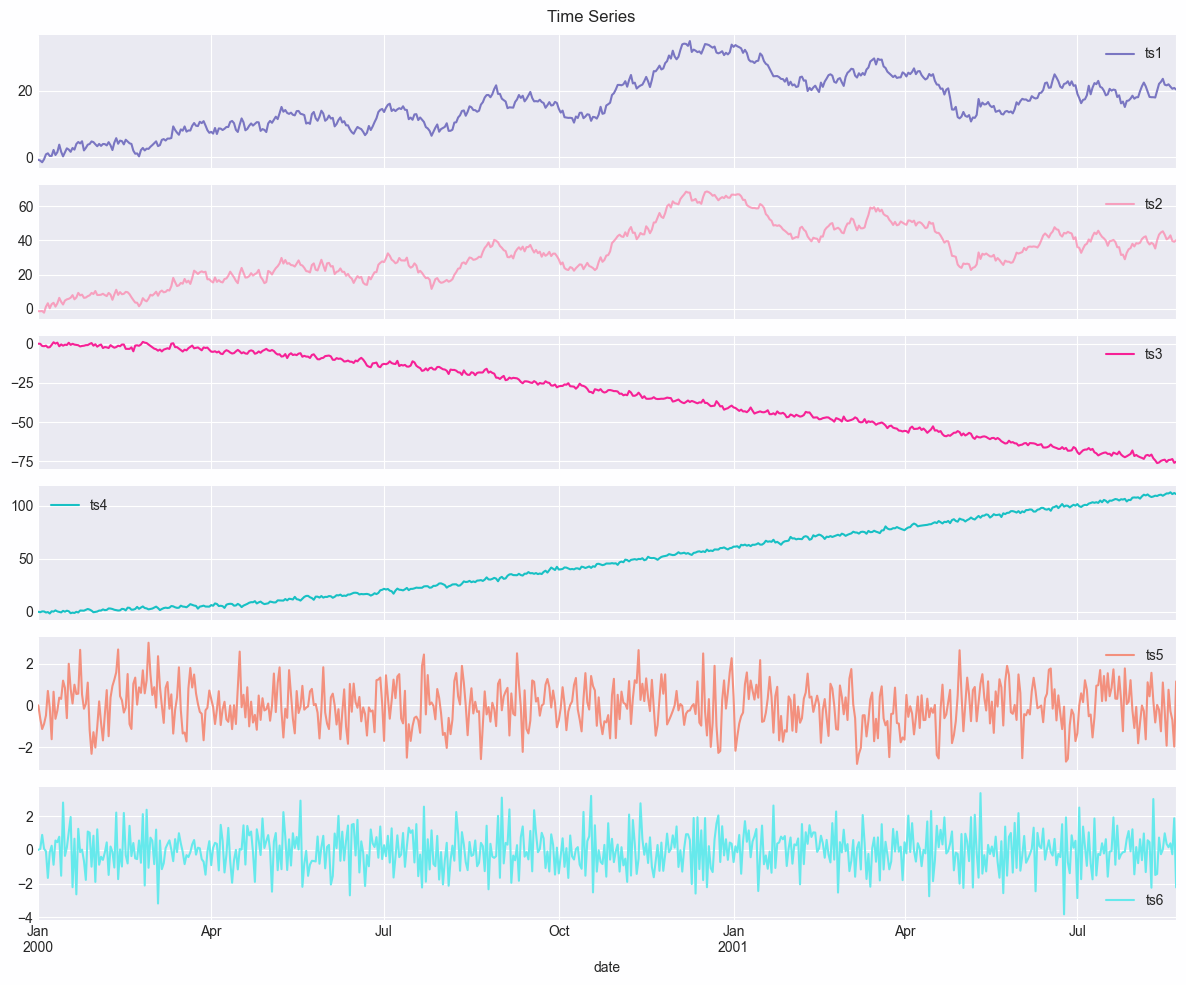

In [3]:
df.plot(subplots=True, figsize=(12,10), title="Time Series")
plt.tight_layout()
plt.show()

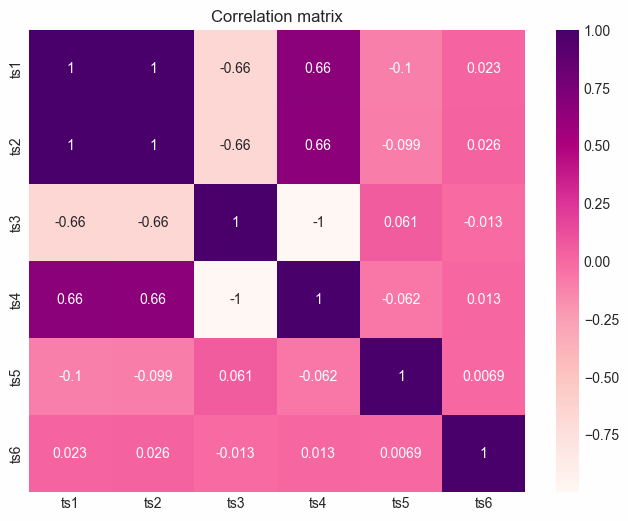

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='RdPu')
plt.title("Correlation matrix")
plt.show()

----

Проверим проядок интегрирования. Сначала как эконометристы: через ADF + KPSS(как проверка ADF)

In [5]:
import warnings
warnings.filterwarnings("ignore")

def adf_test_safe(series):
    try:
        stat, p, _, _, _, _ = adfuller(series.dropna())
        return stat, p
    except Exception:
        return None, None

def kpss_test_safe(series):
    for nlags in ["auto", 16, 12, 8, 4, 2]:
        try:
            stat, p, _, _ = kpss(series.dropna(), regression='c', nlags=nlags)
            return stat, p
        except Exception:
            continue
    return None, None 

def is_stationary(adf_p, kpss_p, alpha=0.05):
    """
    Возвращает True/False, стационарен ли ряд на основе ADF + KPSS,
    с учётом того, что какой-то тест может не сработать.
    """
    adf_res = None
    kpss_res = None

    if adf_p is not None:
        adf_res = "stationary" if adf_p < alpha else "nonstationary"
    if kpss_p is not None:
        kpss_res = "nonstationary" if kpss_p < alpha else "stationary"

    # Оба теста сказали "стационарен"
    if adf_res == "stationary" and kpss_res == "stationary":
        return True
    # Один тест не сработал — опираемся на второй
    if adf_res == "stationary" and kpss_res is None:
        return True
    if kpss_res == "stationary" and adf_res is None:
        return True

    return False

def find_integration_order_clean(series, name, max_d=20):
    print(f"\n=== {name} ===")
    for d in range(max_d + 1):
        x = series if d == 0 else series.diff(d)

        adf_stat, adf_p = adf_test_safe(x)
        kpss_stat, kpss_p = kpss_test_safe(x)

        if is_stationary(adf_p, kpss_p):
            print(f"СТАЦИОНАРЕН при d={d} → {name} ∈ I({d})")
            print(f"ADF:  stat={adf_stat:.4f}, p={adf_p:.5f}")
            print(f"KPSS: stat={kpss_stat:.4f}, p={kpss_p:.5f}")
            return d

    print(f"Не стал стационарным до d={max_d} → порядок интегрирования > {max_d}")
    return None



In [6]:
orders = {}
max_d = 1000

for col in df.columns:
    d = find_integration_order_clean(df[col], col, max_d)
    orders[col] = d

print("\nИТОГ:")
for col, d in orders.items():
    print(f"{col}: I({d})" if d is not None else f"{col}: I(> {max_d})")



=== ts1 ===
СТАЦИОНАРЕН при d=1 → ts1 ∈ I(1)
ADF:  stat=-26.1117, p=0.00000
KPSS: stat=0.1198, p=0.10000

=== ts2 ===
СТАЦИОНАРЕН при d=1 → ts2 ∈ I(1)
ADF:  stat=-24.5267, p=0.00000
KPSS: stat=0.1395, p=0.10000

=== ts3 ===
СТАЦИОНАРЕН при d=585 → ts3 ∈ I(585)
ADF:  stat=-3.4317, p=0.00993
KPSS: stat=0.4260, p=0.06593

=== ts4 ===
СТАЦИОНАРЕН при d=577 → ts4 ∈ I(577)
ADF:  stat=-3.6534, p=0.00482
KPSS: stat=0.4422, p=0.05895

=== ts5 ===
СТАЦИОНАРЕН при d=0 → ts5 ∈ I(0)
ADF:  stat=-18.6948, p=0.00000
KPSS: stat=0.2252, p=0.10000

=== ts6 ===
СТАЦИОНАРЕН при d=0 → ts6 ∈ I(0)
ADF:  stat=-38.5516, p=0.00000
KPSS: stat=0.0585, p=0.10000

ИТОГ:
ts1: I(1)
ts2: I(1)
ts3: I(585)
ts4: I(577)
ts5: I(0)
ts6: I(0)


Очень странные результаты на ```ts3``` и ```ts4```

``` 
ИТОГ:
ts1: I(1)
ts2: I(1)
ts3: I(585)
ts4: I(577)
ts5: I(0)
ts6: I(0)
```

Проверим порядки интегрирования только через ADF, как указано в лекциях:

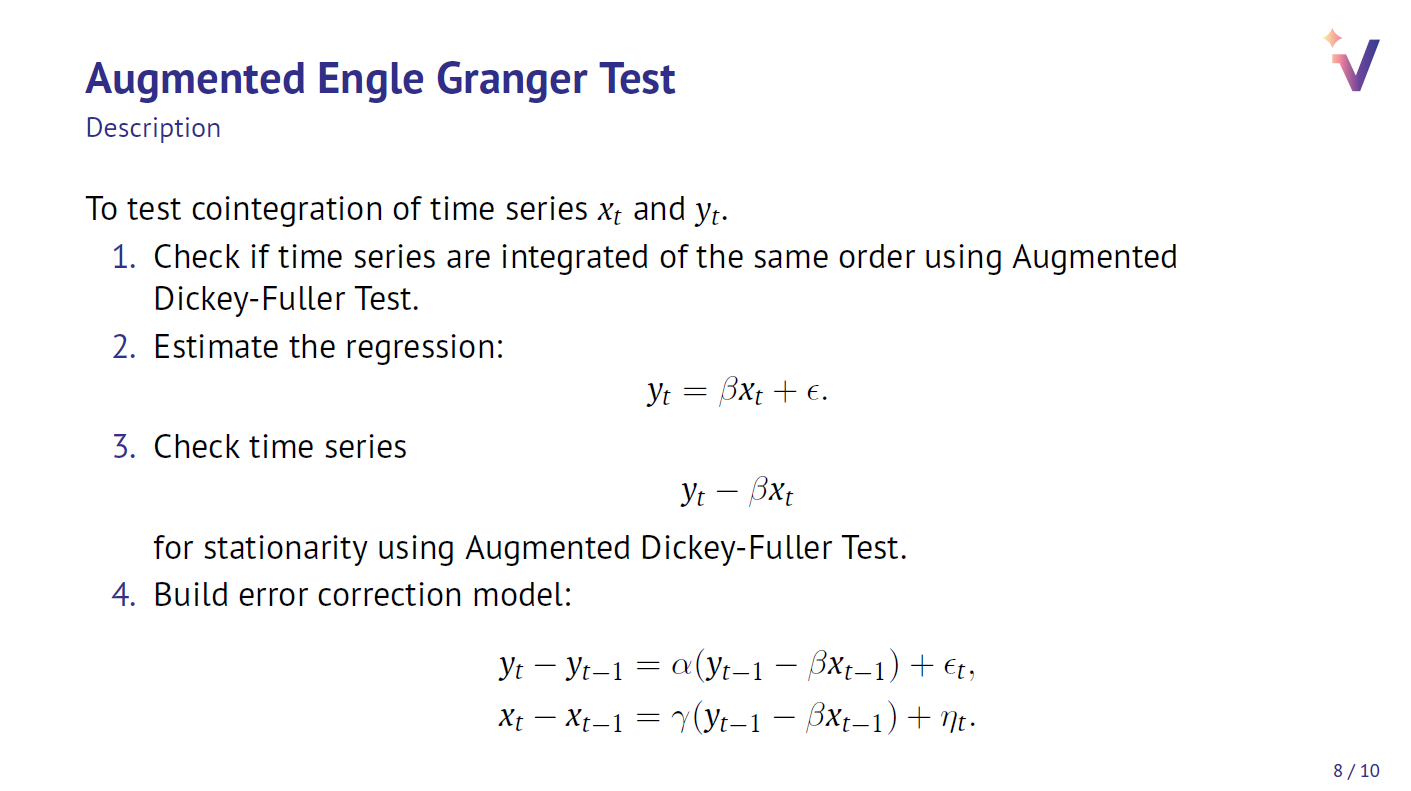

In [7]:
import warnings
warnings.filterwarnings("ignore")

def is_stationary_adf(adf_p, alpha=0.05):
    """
    Стационарен ли ряд по ADF:
    p < alpha → отвергаем H0 → ряд стационарен.
    """
    if adf_p is None:
        return False
    return adf_p < alpha

def find_integration_order_adf(series, name, max_d=1000, alpha=0.05):
    print(f"\n=== {name} ===")
    for d in range(max_d + 1):
        x = series if d == 0 else series.diff(d)

        adf_stat, adf_p = adf_test_safe(x)

        if is_stationary_adf(adf_p, alpha=alpha):
            print(f"СТАЦИОНАРЕН при d={d} по ADF → {name} ∈ I({d})")
            print(f"ADF:  stat={adf_stat:.4f}, p={adf_p:.5f}")
            return d

    print(f"Не стал стационарным по ADF до d={max_d} → порядок интегрирования > {max_d}")
    return None


In [8]:
orders = {}
max_d = 1000 

for col in df.columns:
    d = find_integration_order_adf(df[col], col, max_d=max_d, alpha=0.05)
    orders[col] = d

print("\nИТОГ (только по ADF):")
for col, d in orders.items():
    print(f"{col}: I({d})" if d is not None else f"{col}: I(> {max_d})")


=== ts1 ===
СТАЦИОНАРЕН при d=1 по ADF → ts1 ∈ I(1)
ADF:  stat=-26.1117, p=0.00000

=== ts2 ===
СТАЦИОНАРЕН при d=1 по ADF → ts2 ∈ I(1)
ADF:  stat=-24.5267, p=0.00000

=== ts3 ===
СТАЦИОНАРЕН при d=1 по ADF → ts3 ∈ I(1)
ADF:  stat=-10.7481, p=0.00000

=== ts4 ===
СТАЦИОНАРЕН при d=1 по ADF → ts4 ∈ I(1)
ADF:  stat=-11.5639, p=0.00000

=== ts5 ===
СТАЦИОНАРЕН при d=0 по ADF → ts5 ∈ I(0)
ADF:  stat=-18.6948, p=0.00000

=== ts6 ===
СТАЦИОНАРЕН при d=0 по ADF → ts6 ∈ I(0)
ADF:  stat=-38.5516, p=0.00000

ИТОГ (только по ADF):
ts1: I(1)
ts2: I(1)
ts3: I(1)
ts4: I(1)
ts5: I(0)
ts6: I(0)


```
ИТОГ (только по ADF):
ts1: I(1)
ts2: I(1)
ts3: I(1)
ts4: I(1)
ts5: I(0)
ts6: I(0)
```
Теперь все ок. Можем проверить коинтеграцию между рядами ```ts1-ts2-ts3-ts4```. Так как  ```ts5-ts6``` стационары проверить их коинеграцию мы не можем(коинтеграция -- свойство нестационарных рядов)

In [9]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import pandas as pd

# ---- 1. Engle–Granger тест  ----
def engle_granger_test(x, y):
    # y = β x + ε
    x_const = sm.add_constant(x)
    model = sm.OLS(y, x_const).fit()
    beta = model.params[1]
    resid = model.resid
    stat, pvalue, _, _, _, _ = adfuller(resid)
    return beta, stat, pvalue, resid

# ---- 2. Ищем коинтегрированные пары среди I(1) ----
I1_pairs = [
    ("ts1","ts2"), ("ts1","ts3"), ("ts1","ts4"),
    ("ts2","ts3"), ("ts2","ts4"), ("ts3","ts4")
]

cointegrated = []  

print("\n===== Engle–Granger cointegration tests (I(1) series) =====")
for a, b in I1_pairs:
    beta, stat, p, resid = engle_granger_test(df[a], df[b])
    if p < 0.05:
        print(f"{a} & {b}: КОИНТЕГРИРОВАНЫ (p={p:.4f}), β={beta:.4f}")
        cointegrated.append((a, b, beta))
    else:
        print(f"{a} & {b}: нет коинтеграции (p={p:.4f})")


# ---- 3. Строим ECM для коинтегрированных пар (пункт 4 со слайдов) ----
def build_ecm(x, y, beta, name_x, name_y):
    """
    Строит две модели:
      Δy_t = α (y_{t-1} - β x_{t-1}) + ε_t
      Δx_t = γ (y_{t-1} - β x_{t-1}) + η_t
    и печатает оценки α и γ.
    """
    # лаги уровней
    y_lag = y.shift(1)
    x_lag = x.shift(1)

    # ошибка коинтеграции (error correction term)
    ecm_term = y_lag - beta * x_lag

    # первые разности
    dy = y.diff()
    dx = x.diff()

    data = pd.DataFrame({
        "dy": dy,
        "dx": dx,
        "ecm": ecm_term
    }).dropna()

    # Δy_t = α * ecm_{t-1} + ...
    res_y = sm.OLS(data["dy"], sm.add_constant(data["ecm"])).fit()
    # Δx_t = γ * ecm_{t-1} + ...
    res_x = sm.OLS(data["dx"], sm.add_constant(data["ecm"])).fit()

    alpha = res_y.params["ecm"]
    gamma = res_x.params["ecm"]

    print(f"\n===== ECM для пары {name_y} (y), {name_x} (x) =====")
    print(f"{name_y}: Δ{name_y}_t = α * ( {name_y}_t-1 - β {name_x}_t-1 ) + ε_t")
    print(f"  β (из коинтеграции) = {beta:.4f}")
    print(f"  α (ECM, уравнение для Δ{name_y}) = {alpha:.4f}")

    print(f"\n{name_x}: Δ{name_x}_t = γ * ( {name_y}_t-1 - β {name_x}_t-1 ) + η_t")
    print(f"  β (из коинтеграции) = {beta:.4f}")
    print(f"  γ (ECM, уравнение для Δ{name_x}) = {gamma:.44f}")
    

    return res_y, res_x

print("\n===== Error Correction Models (ECM) для коинтегрированных пар =====")
for x_name, y_name, beta in cointegrated:
    x = df[x_name]
    y = df[y_name]
    build_ecm(x, y, beta, x_name, y_name)





===== Engle–Granger cointegration tests (I(1) series) =====
ts1 & ts2: КОИНТЕГРИРОВАНЫ (p=0.0000), β=1.9798
ts1 & ts3: нет коинтеграции (p=0.8701)
ts1 & ts4: нет коинтеграции (p=0.8451)
ts2 & ts3: нет коинтеграции (p=0.8865)
ts2 & ts4: нет коинтеграции (p=0.8354)
ts3 & ts4: КОИНТЕГРИРОВАНЫ (p=0.0000), β=-1.4882

===== Error Correction Models (ECM) для коинтегрированных пар =====

===== ECM для пары ts2 (y), ts1 (x) =====
ts2: Δts2_t = α * ( ts2_t-1 - β ts1_t-1 ) + ε_t
  β (из коинтеграции) = 1.9798
  α (ECM, уравнение для Δts2) = -0.0892

ts1: Δts1_t = γ * ( ts2_t-1 - β ts1_t-1 ) + η_t
  β (из коинтеграции) = 1.9798
  γ (ECM, уравнение для Δts1) = 0.27616068362408802139285057819506619125604630

===== ECM для пары ts4 (y), ts3 (x) =====
ts4: Δts4_t = α * ( ts4_t-1 - β ts3_t-1 ) + ε_t
  β (из коинтеграции) = -1.4882
  α (ECM, уравнение для Δts4) = -0.1701

ts3: Δts3_t = γ * ( ts4_t-1 - β ts3_t-1 ) + η_t
  β (из коинтеграции) = -1.4882
  γ (ECM, уравнение для Δts3) = -0.20693341059068556